# Implementing a Conditional LLM Router Workflow with LangGraph

In [22]:
from typing import TypedDict, Literal
from langgraph.graph import START, END, StateGraph
from langchain_groq import ChatGroq
from IPython.display import Image   

In [2]:
# Model 
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)


In [3]:
# Workflow State
class WorkflowState(TypedDict):
    question: str
    category: str
    answer: str

In [20]:
# Node Functions :
def input_node(state: WorkflowState) -> WorkflowState:
    """Read and display the input question"""
    print(f"\n[INPUT] Question: {state['question']}")
    return state

def llm_router(state: WorkflowState) -> Literal['math_node', 'general_node']:
    """Use LLM to classify: Is it a math or general question?"""
    prompt = (
        "Classify this question as either 'math' or 'general'.\n"
        "Reply with ONLY one word: 'math' or 'general'. Nothing else.\n\n"
        f"Question: {state['question']}"
    )
    response = llm.invoke(prompt)
    category = response.content.strip().lower()
    
    if category not in ("math", "general"):
        category = "general"
    
    state["category"] = category
    print(f"\n[ROUTER] Classified as: {category.upper()}")
    return category + "_node"

def math_node(state: WorkflowState) -> WorkflowState:
    """Process math questions with detailed explanation"""
    print(f"\n[MATH NODE] Processing math question...")
    
    prompt = (
        "You are a Math Expert. Answer this math question with step-by-step explanation. "
        f"Question: {state['question']}"
    )
    response = llm.invoke(prompt)
    state['answer'] = response.content
    return state

def general_node(state: WorkflowState) -> WorkflowState:
    """Process general questions concisely"""
    print(f"\n[GENERAL NODE] Processing general question...")
    
    prompt = (
        "You are a General Assistant. Answer this question clearly and concisely. "
        f"Question: {state['question']}"
    )
    response = llm.invoke(prompt)
    state['answer'] = response.content
    return state

def final_node(state: WorkflowState) -> WorkflowState:
    """Display final answer"""
    print(f"\n[FINAL NODE] Category: {state['category'].upper()}")
    print(f"[FINAL NODE] Answer:\n{state['answer']}")
    print("\n" + "="*60 + "\n")
    return state

In [17]:
# Initializing the Graph, Nodes and Edges 

builder = StateGraph(WorkflowState)

builder.add_node("input_node",   input_node)
builder.add_node("math_node",    math_node)
builder.add_node("general_node", general_node)
builder.add_node("final_node",   final_node)
 
# Unconditional edges
builder.add_edge(START,          "input_node")
builder.add_edge("math_node",    "final_node")
builder.add_edge("general_node", "final_node")
builder.add_edge("final_node",   END)
 
builder.add_conditional_edges(
    "input_node",        
    llm_router,               
)
 
workflow = builder.compile()

In [18]:
# Executing the graph:
result = workflow.invoke({
        "question": "What is the derivative of x^3 + 2x?",
        "category": "",
        "answer": ""})

print(result)


[INPUT] Question: What is the derivative of x^3 + 2x?

[ROUTER] Classified as: MATH

[MATH NODE] Processing math question...

[FINAL NODE] Category: 
[FINAL NODE] Answer:
To find the derivative of x^3 + 2x, we'll apply the power rule of differentiation, which states that if f(x) = x^n, then f'(x) = nx^(n-1).

Here's the step-by-step solution:

1. **Identify the terms**: The given function is x^3 + 2x. It has two terms: x^3 and 2x.

2. **Apply the power rule to each term**:
   - For the term x^3, the exponent (n) is 3. Using the power rule, the derivative of x^3 is 3x^(3-1) = 3x^2.
   - For the term 2x, we can rewrite 2x as 2x^1, where the exponent (n) is 1. Using the power rule, the derivative of 2x^1 is 2(1)x^(1-1) = 2x^0. Since x^0 = 1 (any non-zero number raised to the power of 0 is 1), the derivative of 2x is 2.

3. **Combine the derivatives of the terms**: The derivative of x^3 + 2x is the sum of the derivatives of each term, which is 3x^2 + 2.

Therefore, the derivative of x^3 +

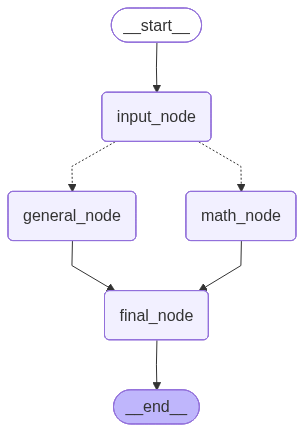

In [23]:
Image(workflow.get_graph().draw_mermaid_png())